## Data Understanding & Cleaning


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/car data.csv')

In [6]:
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
print("Shape: ", df.shape)

print("\nColumns: ")
print(df.columns)

print("\nData types: ")
print(df.dtypes)

Shape:  (301, 9)

Columns: 
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Data types: 
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object


In [8]:
print("Missing Values: ")
print(df.isnull().sum())

Missing Values: 
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df = df.drop_duplicates()

print("Shape: ", df.shape)

print("\nDuplicate Values: ", df.duplicated().sum())

Shape:  (299, 9)

Duplicate Values:  0


In [11]:
#Basic statistics for numerical columns
print(df.describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   299.000000     299.000000     299.000000     299.000000  299.000000
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478
std       2.896868       4.984240       8.566332   39015.170352    0.248720
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [12]:
#Unique values in categorical columns
print(df["Car_Name"].value_counts())
print("\n")
print("Unqiue Car names: ",df['Car_Name'].unique())
print(df["Fuel_Type"].value_counts())
print("\n")
print(df["Selling_type"].value_counts())
print("\n")
print(df["Transmission"].value_counts())
print("\n")
print(df["Owner"].value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
brio                  10
fortuner              10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


Unqiue Car names:  ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 16

## EDA & Visualization

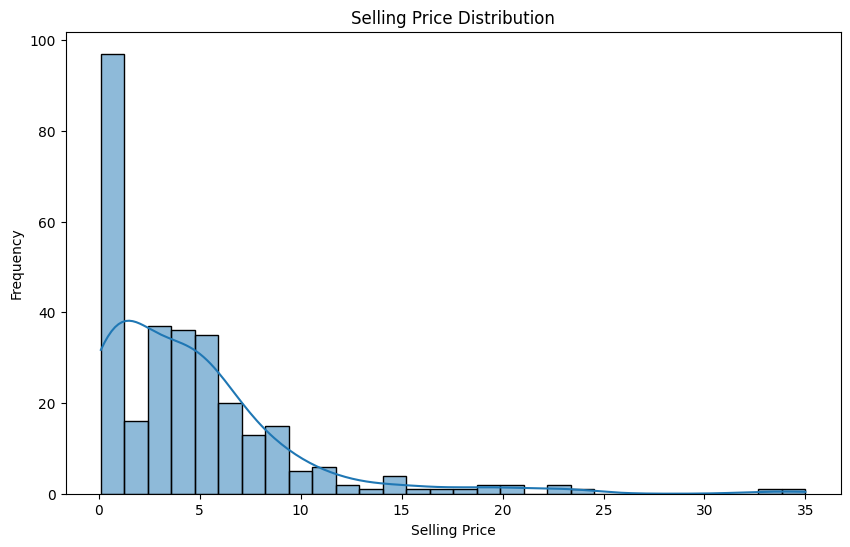

In [13]:
# Selling Price Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

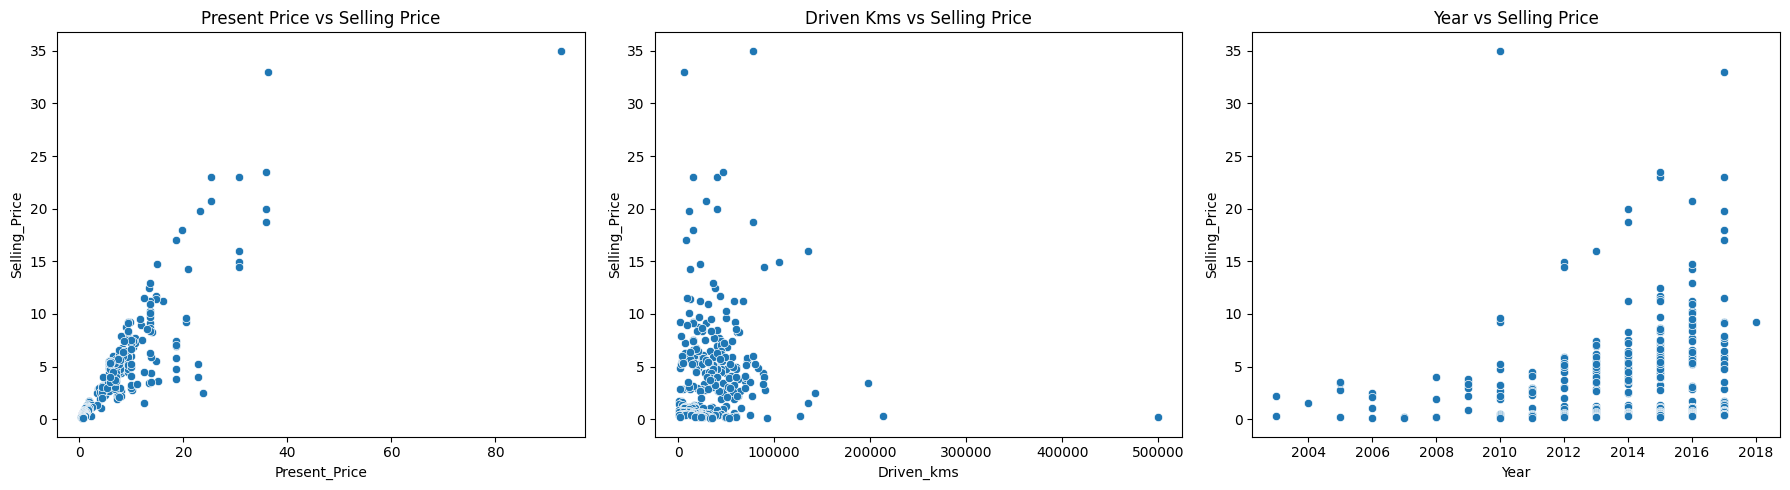

In [14]:
# Numerical Features vs Selling Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Present Price vs Selling Price
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", ax=axes[0])
axes[0].set_title("Present Price vs Selling Price")

# Driven Kms vs Selling Price
sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price", ax=axes[1])
axes[1].set_title("Driven Kms vs Selling Price")

# Year vs Selling Price
sns.scatterplot(data=df, x="Year", y="Selling_Price", ax=axes[2])
axes[2].set_title("Year vs Selling Price")

plt.tight_layout()
plt.show()


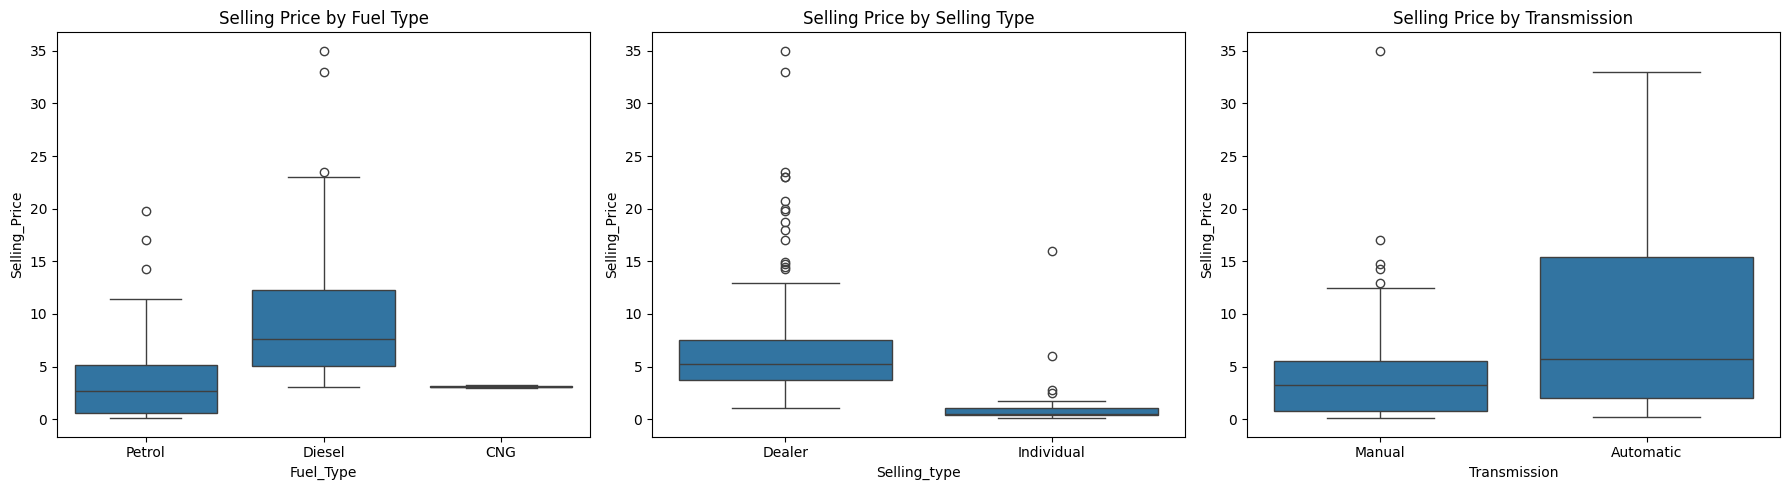

In [15]:
# Catogerical Features vs Selling Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#fuel type vs selling price
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", ax=axes[0])
axes[0].set_title("Selling Price by Fuel Type")

#selling type vs selling price
sns.boxplot(data=df, x="Selling_type", y="Selling_Price", ax=axes[1])
axes[1].set_title("Selling Price by Selling Type")

#transmission vs selling price
sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[2])
axes[2].set_title("Selling Price by Transmission")

plt.tight_layout()
plt.show()

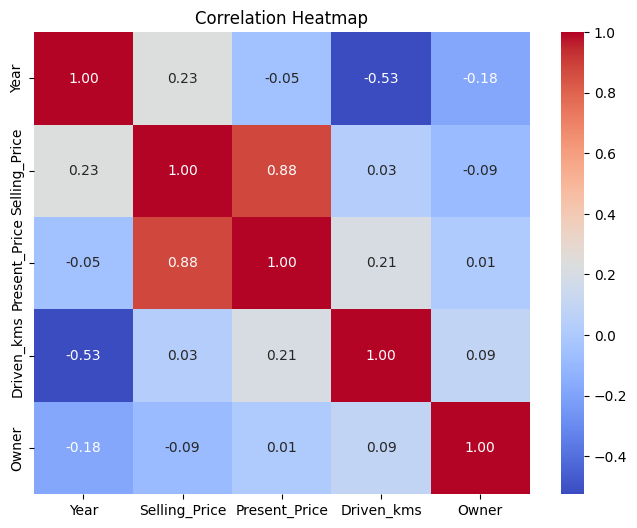

In [16]:
#Correlation HeatMap
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Preprocessing & Model Building

In [17]:
#Choosing Feature and Target
X = df.drop(columns=["Selling_Price", "Car_Name"])
y = df["Selling_Price"]

In [19]:
print("Features: ")
print(X.head())

print("\nTarget: ")
print(y.head())

Features: 
   Year  Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner
0  2014           5.59       27000    Petrol       Dealer       Manual      0
1  2013           9.54       43000    Diesel       Dealer       Manual      0
2  2017           9.85        6900    Petrol       Dealer       Manual      0
3  2011           4.15        5200    Petrol       Dealer       Manual      0
4  2014           6.87       42450    Diesel       Dealer       Manual      0

Target: 
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [27]:
categorical_features = ["Fuel_Type", "Selling_type", "Transmission"]
numerical_features = ["Year", "Present_Price", "Driven_kms", "Owner"]


In [28]:
# Covert Categorical Data into Numbers
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [29]:
#train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (239, 7)
X_test:  (60, 7)
y_train:  (239,)
y_test:  (60,)


In [32]:
#Building regression model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission'])])),
                ('model', LinearRegression())])

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

## Evaluation & Results

In [34]:
# Make Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [36]:
#calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression metrics
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Linear Regression
MAE: 1.4725457508177218
RMSE: 2.5245049230011913
R²: 0.7527233824221826

Random Forest
MAE: 1.5253741666666667
RMSE: 3.6721173509241702
R²: 0.47680484826900227


In [37]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R²": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.472546,2.524505,0.752723
1,Random Forest,1.525374,3.672117,0.476805


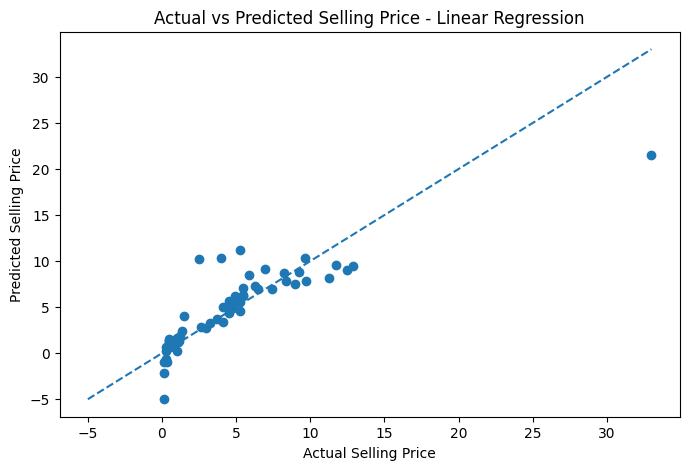

In [40]:
#Actual vs Prediction Visualization
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_linear)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price - Linear Regression")

plt.show()

# Key finding
From the EDA and models:
1. Present Price has the strongest relationship with Selling Price, with a correlation of about 0.88.
2. Year shows a positive relationship with Selling Price, meaning newer cars generally tend to have higher selling prices.
3. Driven Kms has a weak linear relationship with Selling Price in this dataset.
4. Categorical features such as Fuel Type, Selling Type, and Transmission show differences in selling-price distributions.
5. Linear Regression achieved:
   - MAE: 1.47 lakhs
   - RMSE: 2.52 lakhs
   - R²: 0.753
6. Random Forest achieved:
   - MAE: 1.53 lakhs
   - RMSE: 3.67 lakhs
   - R²: 0.477
7. The actual-vs-predicted plot shows that most Linear Regression predictions are relatively close to the perfect-prediction line.